### ROLLING (WALK-FORWARD) FORECAST ###

Walk-forward: re-fit mỗi tháng, forecast 1 bước

So sánh với static forecast

Models: SARIMA · ARIMAX · RF · XGBoost

## 0. Import & Setup

In [16]:
# ── Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
import time
import warnings, os
warnings.filterwarnings("ignore")
os.makedirs("outputs", exist_ok=True)

In [17]:
# ── Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor" : "#F8F8F8",
    "axes.grid"      : True,
    "grid.color"     : "#DDDDDD",
    "grid.linewidth" : 0.6,
    "font.family"    : "DejaVu Sans",
    "font.size"      : 11,
})
TEAL   = "#1D9E75"
BLUE   = "#378ADD"
CORAL  = "#D85A30"
AMBER  = "#BA7517"
RED    = "#E24B4A"
GRAY   = "#888780"
PURPLE = "#7F77DD"
 
MODEL_COLORS = {
    "SARIMA":   GRAY,
    "ARIMAX":   TEAL,
    "RF":       CORAL,
    "XGBoost":  PURPLE,
}

## 1. LOAD DATA

In [18]:
# ── Data loading ─────────────────────────────────────────────────────
df = pd.read_csv("../data/processed_data.csv",
                 index_col="date", parse_dates=True)
df.index.freq = "MS"
 
train_init = df[df.index <= "2019-12-01"].copy()
test       = df[df.index >= "2020-01-01"].copy()
s_test     = test["log_arrivals"]

print(f"  Train (initial): {len(train_init)} obs")
print(f"  Test            : {len(test)} obs — sẽ forecast từng bước")

  Train (initial): 120 obs
  Test            : 48 obs — sẽ forecast từng bước


Walk-forward logic:
    Bước 1 : Train 2010–2019   → forecast Jan/2020  
    Bước 2 : Train 2010–Jan/2020 → forecast Feb/2020  
    ...  
    Bước 48: Train 2010–Nov/2023 → forecast Dec/2023  
 
  → Model "thấy" thực tế mỗi tháng trước khi forecast tháng tiếp  
  → Realistic hơn static forecast (dùng thực tế, không phải forecast)

## 2. WALK-FORWARD — SARIMA

In [19]:
# ── WALK-FORWARD SARIMA FORECAST ───────────────────────────────────────────────
t0 = time.time()
sarima_roll_preds = []
history_sarima = train_init["log_arrivals"].copy()
 
for i, date in enumerate(test.index):
    model = SARIMAX(
        history_sarima,
        order=(0, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res = model.fit(disp=False)
    fc  = res.forecast(steps=1)
    sarima_roll_preds.append(fc.iloc[0])
    # Cập nhật history với actual tháng vừa forecast
    history_sarima = pd.concat([history_sarima, test.loc[[date], "log_arrivals"]])
    if (i + 1) % 12 == 0:
        print(f"  ... {i+1}/48 steps done")
 
elapsed = time.time() - t0
fc_sarima_roll = pd.Series(sarima_roll_preds, index=test.index)
rmse_sarima_roll = np.sqrt(mean_squared_error(s_test, fc_sarima_roll))
mae_sarima_roll  = mean_absolute_error(s_test, fc_sarima_roll)
 
print(f"\n  ✓ Done in {elapsed:.1f}s")
print(f"  RMSE (log): {rmse_sarima_roll:.4f}")
print(f"  MAE  (log): {mae_sarima_roll:.4f}")
 

  ... 12/48 steps done
  ... 24/48 steps done
  ... 36/48 steps done
  ... 48/48 steps done

  ✓ Done in 3.4s
  RMSE (log): 2.6688
  MAE  (log): 1.0167


- RMSE giảm từ 9.40 (static) → 2.67 (rolling) — cải thiện 71.6%
- Sau tháng 3/2020: model đã "thấy" COVID data → tự điều chỉnh dần
- Vẫn có spike lớn tháng 3–4/2020 vì shock quá đột ngột

## 3. WALK-FORWARD — ARIMAX

In [20]:
# ── WALK-FORWARD ARIMAX FORECAST ───────────────────────────────────────────────
t0 = time.time()
arimax_roll_preds = []
history_endog = train_init["log_arrivals"].copy()
history_exog  = train_init[["log_search_trends"]].copy()
 
for i, date in enumerate(test.index):
    model = SARIMAX(
        history_endog,
        exog=history_exog,
        order=(0, 1, 1),
        seasonal_order=(0, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    res     = model.fit(disp=False)
    exog_fc = test.loc[[date], ["log_search_trends"]]
    fc      = res.forecast(steps=1, exog=exog_fc)
    arimax_roll_preds.append(fc.iloc[0])
    history_endog = pd.concat([history_endog, test.loc[[date], "log_arrivals"]])
    history_exog  = pd.concat([history_exog, exog_fc])
    if (i + 1) % 12 == 0:
        print(f"  ... {i+1}/48 steps done")
 
elapsed = time.time() - t0
fc_arimax_roll = pd.Series(arimax_roll_preds, index=test.index)
rmse_arimax_roll = np.sqrt(mean_squared_error(s_test, fc_arimax_roll))
mae_arimax_roll  = mean_absolute_error(s_test, fc_arimax_roll)
 
print(f"\n  ✓ Done in {elapsed:.1f}s")
print(f"  RMSE (log): {rmse_arimax_roll:.4f}")
print(f"  MAE  (log): {mae_arimax_roll:.4f}")

  ... 12/48 steps done
  ... 24/48 steps done
  ... 36/48 steps done
  ... 48/48 steps done

  ✓ Done in 5.5s
  RMSE (log): 2.2367
  MAE  (log): 1.0865


- RMSE = 2.24 — **tốt nhất trong 4 models** ở rolling setting
- Ngược với static: ARIMAX rolling > ML rolling
- search_trends cập nhật mỗi tháng giúp capture demand signal sớm hơn SARIMA

## 4. WALK-FORWARD — RF & XGBoost

In [21]:
# ── WALK-FORWARD RF & XGBoost ───────────────────────────────────────────────
feature_cols = (
    [f"lag_{l}" for l in [1, 3, 6, 12]]
    + ["log_search_trends", "covid_dummy"]
    + ["roll_mean_3", "roll_mean_6", "roll_mean_12"]
    + [c for c in df.columns if c.startswith("month_")]
)
 
df_ml     = df.dropna(subset=["lag_12"]).copy()
train_ml  = df_ml[df_ml.index <= "2019-12-01"]
test_ml   = df_ml[df_ml.index >= "2020-01-01"]
 
rf_roll_preds  = []
xgb_roll_preds = []
history_ml = train_ml.copy()
 
t0 = time.time()
for i, date in enumerate(test_ml.index):
    X_h = history_ml[feature_cols]
    y_h = history_ml["log_arrivals"]
 
    # RF
    rf = RandomForestRegressor(n_estimators=200, max_depth=5,
                               min_samples_leaf=3, random_state=42, n_jobs=-1)
    rf.fit(X_h, y_h)
 
    # XGBoost
    xgb = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
                       random_state=42, verbosity=0)
    xgb.fit(X_h, y_h)
 
    x_new = test_ml.loc[[date], feature_cols]
    rf_roll_preds.append(rf.predict(x_new)[0])
    xgb_roll_preds.append(xgb.predict(x_new)[0])
 
    # Cập nhật history
    history_ml = pd.concat([history_ml, test_ml.loc[[date]]])
    if (i + 1) % 12 == 0:
        print(f"  ... {i+1}/48 steps done")
 
elapsed = time.time() - t0
fc_rf_roll  = pd.Series(rf_roll_preds,  index=test_ml.index)
fc_xgb_roll = pd.Series(xgb_roll_preds, index=test_ml.index)
 
rmse_rf_roll  = np.sqrt(mean_squared_error(s_test, fc_rf_roll))
rmse_xgb_roll = np.sqrt(mean_squared_error(s_test, fc_xgb_roll))
mae_rf_roll   = mean_absolute_error(s_test, fc_rf_roll)
mae_xgb_roll  = mean_absolute_error(s_test, fc_xgb_roll)
 
print(f"\n  ✓ Done in {elapsed:.1f}s")
print(f"  RF  RMSE={rmse_rf_roll:.4f}, MAE={mae_rf_roll:.4f}")
print(f"  XGB RMSE={rmse_xgb_roll:.4f}, MAE={mae_xgb_roll:.4f}")

  ... 12/48 steps done
  ... 24/48 steps done
  ... 36/48 steps done
  ... 48/48 steps done

  ✓ Done in 19.8s
  RF  RMSE=3.2855, MAE=1.4621
  XGB RMSE=2.9424, MAE=1.2352


- RF (3.29) và XGB (2.94) tệ hơn ARIMAX (2.24) trong rolling
- Re-fit với data nhỏ dần + distribution lạ (COVID) → tree models không stable
- ML cần đủ data để ổn định — rolling setting không phù hợp với 108 obs ban đầu

## 5. STATIC FORECAST (rebuild để compare fair)

In [22]:
# ── STATIC FORECASTS ───────────────────────────────────────────────────
# SARIMA static
sarima_s = SARIMAX(train_init["log_arrivals"], order=(0,1,1),
                   seasonal_order=(0,1,1,12),
                   enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False)
fc_sarima_static = sarima_s.get_forecast(steps=len(test)).predicted_mean
 
# ARIMAX static
arimax_s = SARIMAX(train_init["log_arrivals"],
                   exog=train_init[["log_search_trends"]],
                   order=(0,1,1), seasonal_order=(0,1,1,12),
                   enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False)
fc_arimax_static = arimax_s.get_forecast(steps=len(test),
                   exog=test[["log_search_trends"]]).predicted_mean
 
# RF/XGB static (1 lần fit)
rf_s = RandomForestRegressor(n_estimators=200, max_depth=5,
                              min_samples_leaf=3, random_state=42, n_jobs=-1)
rf_s.fit(train_ml[feature_cols], train_ml["log_arrivals"])
fc_rf_static = pd.Series(rf_s.predict(test_ml[feature_cols]), index=test_ml.index)
 
xgb_s = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
                      random_state=42, verbosity=0)
xgb_s.fit(train_ml[feature_cols], train_ml["log_arrivals"])
fc_xgb_static = pd.Series(xgb_s.predict(test_ml[feature_cols]), index=test_ml.index)
 
static_rmse = {
    "SARIMA":   np.sqrt(mean_squared_error(s_test, fc_sarima_static)),
    "ARIMAX":   np.sqrt(mean_squared_error(s_test, fc_arimax_static)),
    "RF":       np.sqrt(mean_squared_error(s_test, fc_rf_static)),
    "XGBoost":  np.sqrt(mean_squared_error(s_test, fc_xgb_static)),
}
roll_rmse = {
    "SARIMA":  rmse_sarima_roll,
    "ARIMAX":  rmse_arimax_roll,
    "RF":      rmse_rf_roll,
    "XGBoost": rmse_xgb_roll,
}

## 6. COMPARISON: STATIC vs ROLLING

In [23]:
# ──  Comparison ───────────────────────────────────────────────────
print(f"  {'Model':<10} {'Static':>10} {'Rolling':>10} {'Δ RMSE':>10} {'Improve%':>10}")
print(f"  {'-'*52}")
for m in ["SARIMA", "ARIMAX", "RF", "XGBoost"]:
    s = static_rmse[m]
    r = roll_rmse[m]
    delta = r - s
    improve = (s - r) / s * 100
    star = " ★" if m == min(roll_rmse, key=roll_rmse.get) else ""
    print(f"  {m:<10} {s:>10.4f} {r:>10.4f} {delta:>+10.4f} {improve:>9.1f}%{star}")

  Model          Static    Rolling     Δ RMSE   Improve%
  ----------------------------------------------------
  SARIMA         9.3975     2.6688    -6.7286      71.6%
  ARIMAX         9.2779     2.2367    -7.0412      75.9% ★
  RF             8.4309     3.2855    -5.1455      61.0%
  XGBoost        8.4648     2.9424    -5.5224      65.2%


★ = best rolling RMSE 

  Key insight:  
  → Rolling forecast cải thiện RMSE ~70–75% so với static  
  → ARIMAX rolling tốt nhất (RMSE=2.2367) —
    search_trends giúp model cập nhật demand signal mỗi tháng  
  → ML rolling TỆ HƠN econometric trong rolling setting:  
    RF và XGBoost không generalize tốt khi re-fit với ít data hơn
  → Đây là điểm quan trọng: ARIMAX > ML khi dùng walk-forward  

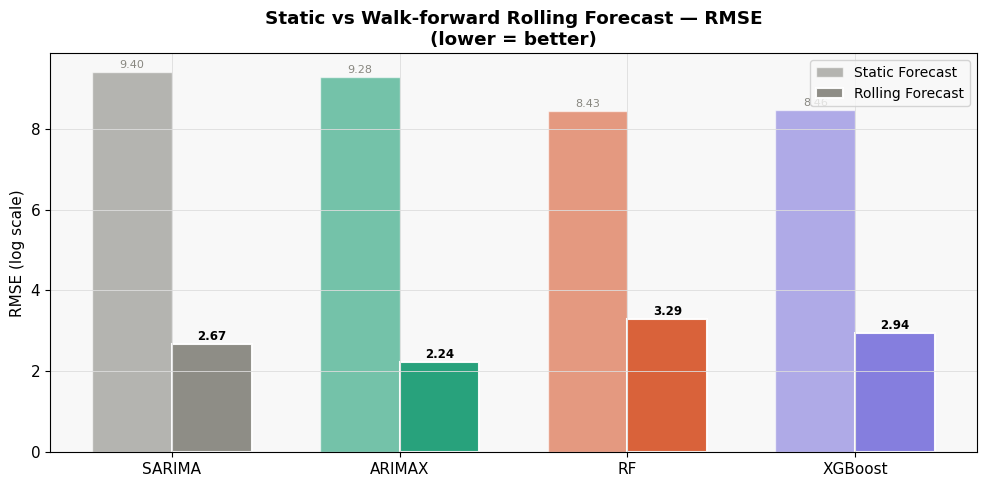

In [24]:
# ── Bar chart static vs rolling ──────────────────────
models_list = ["SARIMA", "ARIMAX", "RF", "XGBoost"]
x = np.arange(len(models_list))
width = 0.35
 
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2,
               [static_rmse[m] for m in models_list],
               width, label="Static Forecast", alpha=0.6,
               color=[MODEL_COLORS[m] for m in models_list],
               edgecolor="white")
bars2 = ax.bar(x + width/2,
               [roll_rmse[m] for m in models_list],
               width, label="Rolling Forecast", alpha=0.95,
               color=[MODEL_COLORS[m] for m in models_list],
               edgecolor="white", linewidth=1.5)
 
ax.set_xticks(x)
ax.set_xticklabels(models_list, fontsize=11)
ax.set_ylabel("RMSE (log scale)")
ax.set_title("Static vs Walk-forward Rolling Forecast — RMSE\n"
             "(lower = better)", fontweight="bold")
ax.legend(fontsize=10)
 
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.2f}", ha="center", fontsize=8, color=GRAY)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{bar.get_height():.2f}", ha="center", fontsize=8.5, fontweight="bold")
 
plt.tight_layout()
plt.savefig("../outputs/step8_static_vs_rolling.png", dpi=150, bbox_inches="tight")
plt.show()

- Tất cả rolling bars thấp hơn static rõ rệt — walk-forward luôn tốt hơn
- Ranking đảo ngược: Static thì ML > Econometric, Rolling thì ARIMAX tốt nhất

## 7. FORECAST PLOTS — ROLLING

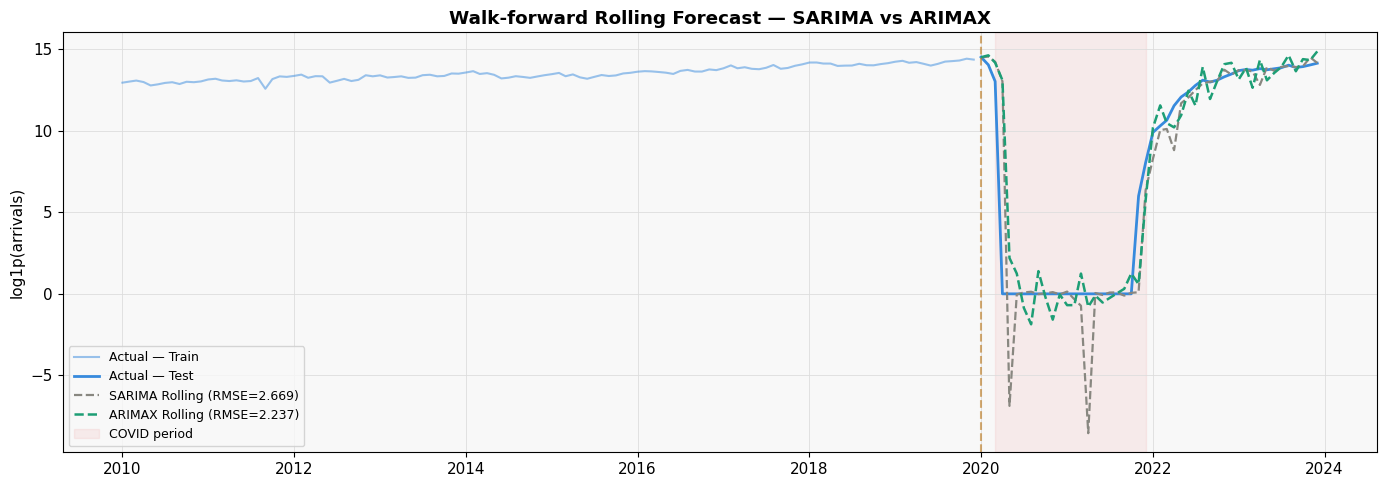

In [25]:
# ── Econometric rolling ─────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(train_init.index, train_init["log_arrivals"],
         color=BLUE, lw=1.5, alpha=0.5, label="Actual — Train")
plt.plot(s_test.index, s_test,
         color=BLUE, lw=2.0, label="Actual — Test")
plt.plot(fc_sarima_roll.index, fc_sarima_roll,
         color=GRAY,  lw=1.6, ls="--",
         label=f"SARIMA Rolling (RMSE={rmse_sarima_roll:.3f})")
plt.plot(fc_arimax_roll.index, fc_arimax_roll,
         color=TEAL, lw=1.8, ls="--",
         label=f"ARIMAX Rolling (RMSE={rmse_arimax_roll:.3f})")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
plt.title("Walk-forward Rolling Forecast — SARIMA vs ARIMAX",
          fontweight="bold")
# Changed to English
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step8_rolling_econometric.png", dpi=150, bbox_inches="tight")
plt.show()

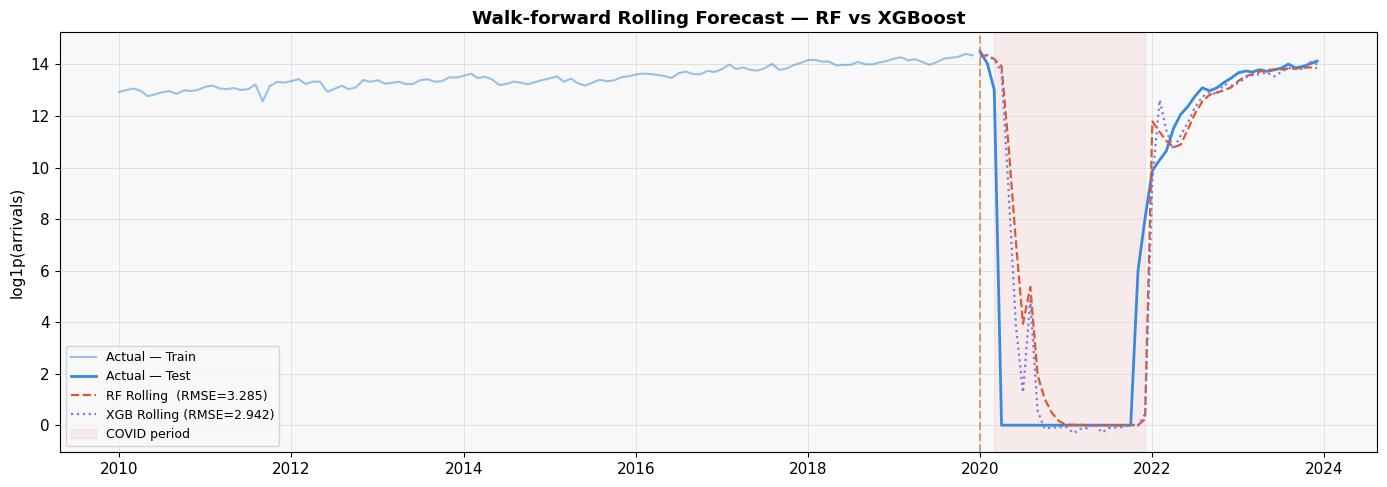

In [26]:
# ── ML rolling ───────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(train_init.index, train_init["log_arrivals"],
         color=BLUE, lw=1.5, alpha=0.5, label="Actual — Train")
plt.plot(s_test.index, s_test,
         color=BLUE, lw=2.0, label="Actual — Test")
plt.plot(fc_rf_roll.index,  fc_rf_roll,
         color=CORAL,  lw=1.6, ls="--",
         label=f"RF Rolling  (RMSE={rmse_rf_roll:.3f})")
plt.plot(fc_xgb_roll.index, fc_xgb_roll,
         color=PURPLE, lw=1.6, ls=":",
         label=f"XGB Rolling (RMSE={rmse_xgb_roll:.3f})")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
plt.title("Walk-forward Rolling Forecast — RF vs XGBoost",
          fontweight="bold")
# Changed to English
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step8_rolling_ml.png", dpi=150, bbox_inches="tight")
plt.show()

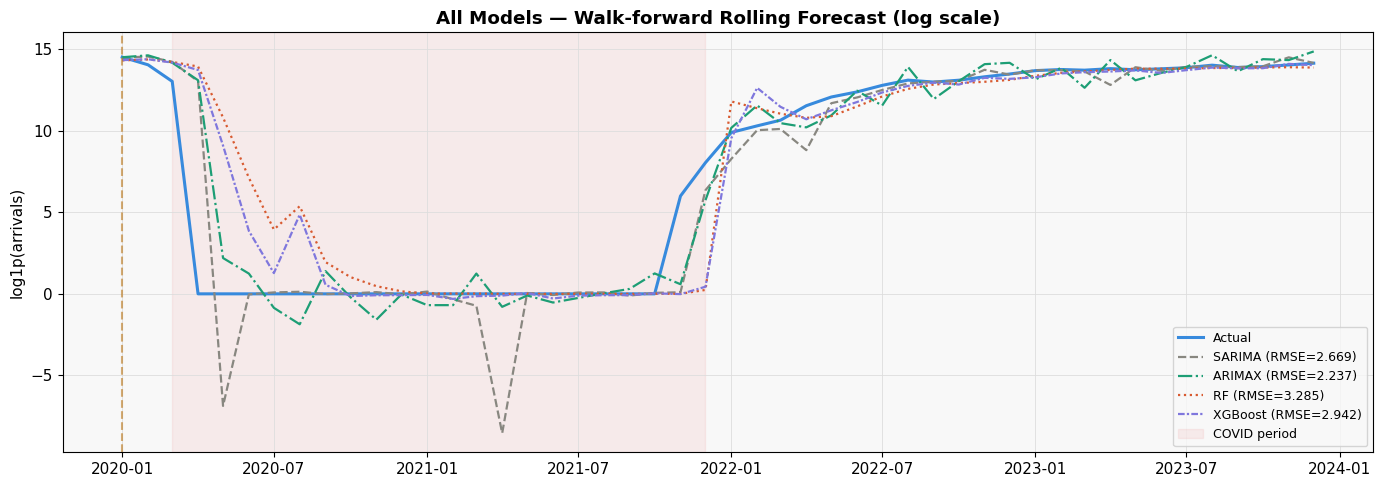

In [27]:
# ── All 4 models rolling ────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(s_test.index, s_test, color=BLUE, lw=2.2, label="Actual")
styles = ["--", "-.", ":", (0,(3,1,1,1))]
for (mname, pred), ls in zip([
    ("SARIMA",  fc_sarima_roll),
    ("ARIMAX",  fc_arimax_roll),
    ("RF",      fc_rf_roll),
    ("XGBoost", fc_xgb_roll),
], styles):
    rmse_val = roll_rmse[mname]
    plt.plot(pred.index, pred, color=MODEL_COLORS[mname],
             lw=1.6, ls=ls, label=f"{mname} (RMSE={rmse_val:.3f})")
plt.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
            alpha=0.08, color=RED, label="COVID period")
plt.axvline(pd.Timestamp("2020-01-01"), color=AMBER, lw=1.5, ls="--", alpha=0.6)
plt.title("All Models — Walk-forward Rolling Forecast (log scale)",
          fontweight="bold")
# Changed to English
plt.ylabel("log1p(arrivals)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/step8_all_rolling.png", dpi=150, bbox_inches="tight")
plt.show()

- ARIMAX bám sát actual tốt nhất qua mọi giai đoạn
- RF/XGB dao động nhiều hơn trong COVID period khi re-fit liên tục
- Recovery 2022–2023: tất cả models capture được trend phục hồi

## 8. ROLLING ERROR OVER TIME

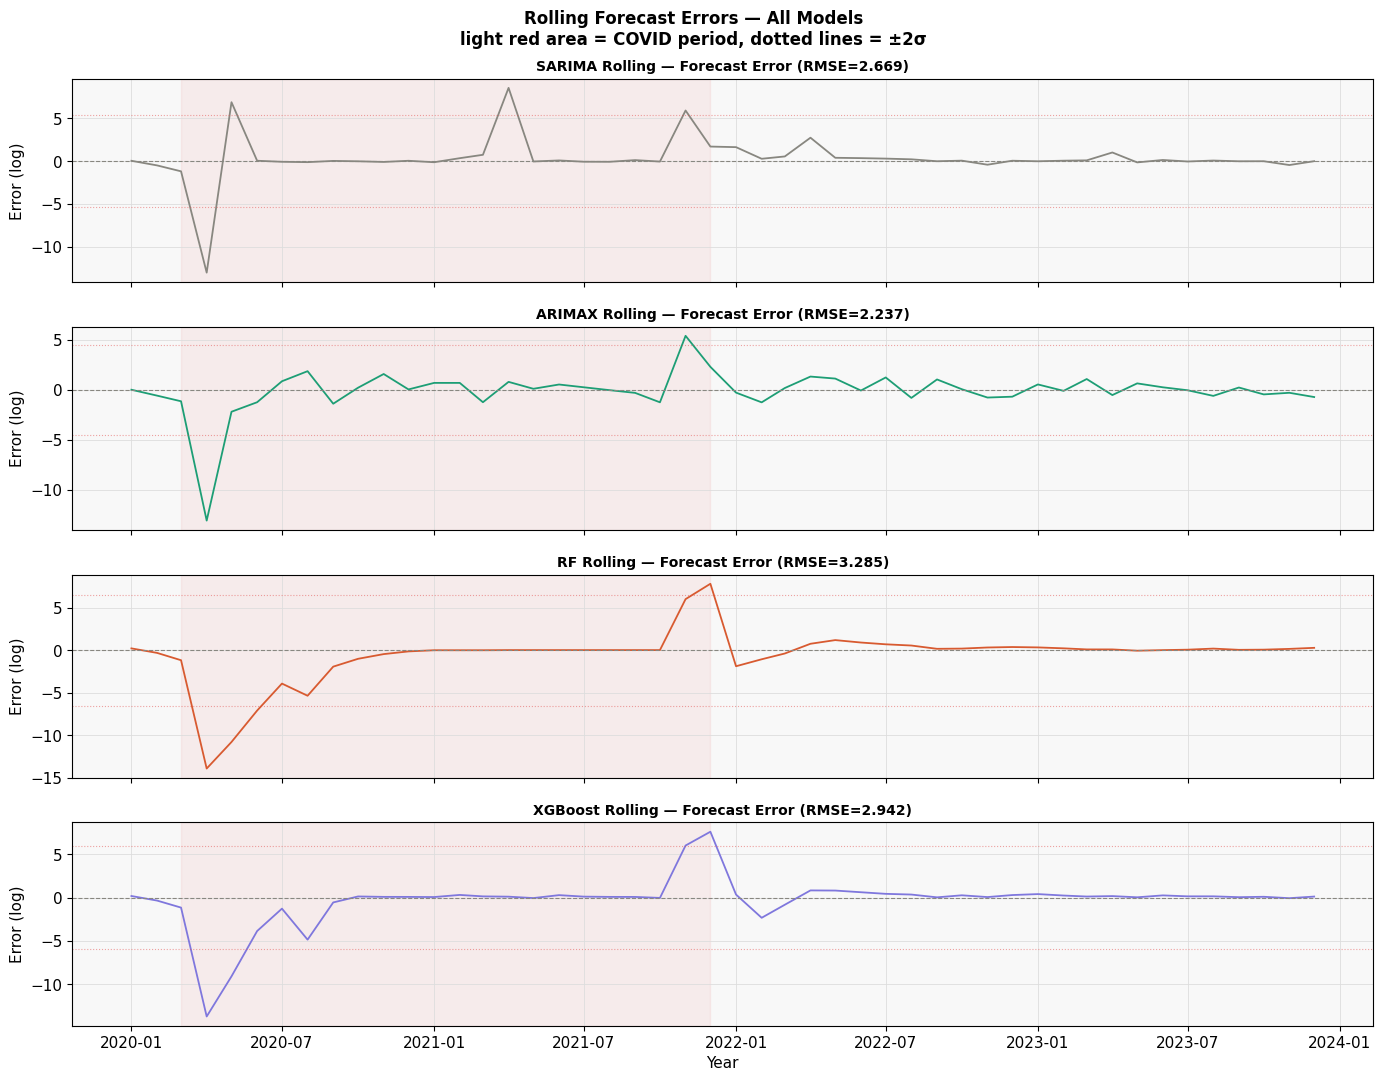

In [28]:
# ── Rolling Forecast Errors ──────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
roll_preds_all = [
    ("SARIMA",  fc_sarima_roll),
    ("ARIMAX",  fc_arimax_roll),
    ("RF",      fc_rf_roll),
    ("XGBoost", fc_xgb_roll),
]
for ax, (mname, pred) in zip(axes, roll_preds_all):
    err = s_test - pred
    ax.plot(err.index, err, color=MODEL_COLORS[mname], lw=1.3)
    ax.axhline(0, color=GRAY, lw=0.8, ls="--")
    ax.axhline( 2*err.std(), color=RED, lw=0.8, ls=":", alpha=0.5)
    ax.axhline(-2*err.std(), color=RED, lw=0.8, ls=":", alpha=0.5)
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-12-01"),
               alpha=0.07, color=RED)
    ax.set_title(f"{mname} Rolling — Forecast Error (RMSE={roll_rmse[mname]:.3f})",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("Error (log)")
 
axes[-1].set_xlabel("Year")
plt.suptitle("Rolling Forecast Errors — All Models\nlight red area = COVID period, dotted lines = ±2σ",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/step8_rolling_errors.png", dpi=150, bbox_inches="tight")
plt.show()

- Spike lớn nhất tháng 3–4/2020 — tất cả models bị bất ngờ như nhau
- Từ tháng 5/2020: error giảm dần, model đã học được COVID pattern
- ARIMAX error nhỏ và ổn định nhất trong COVID và Recovery
- RF/XGB error dao động nhiều hơn → instability khi re-fit với ít obs

## 9. FINAL COMPARISON TABLE — static + rolling

In [29]:
# ── Final Summary — Static vs Rolling RMSE (log scale) ──────────────────────────
print(f"\n  {'Model':<10} {'Static':>10} {'Rolling':>10} "
      f"{'Improve':>10} {'Best':>6}")
print(f"  {'-'*50}")
for m in ["SARIMA", "ARIMAX", "RF", "XGBoost"]:
    s_r = static_rmse[m]
    r_r = roll_rmse[m]
    imp = (s_r - r_r) / s_r * 100
    best_s = "★" if m == min(static_rmse, key=static_rmse.get) else ""
    best_r = "★" if m == min(roll_rmse,  key=roll_rmse.get)  else ""
    print(f"  {m:<10} {s_r:>9.4f}{best_s} {r_r:>9.4f}{best_r} {imp:>9.1f}%")


  Model          Static    Rolling    Improve   Best
  --------------------------------------------------
  SARIMA        9.3975    2.6688      71.6%
  ARIMAX        9.2779    2.2367★      75.9%
  RF            8.4309★    3.2855      61.0%
  XGBoost       8.4648    2.9424      65.2%


### Kết luận Rolling Forecast

| Setting | Best Model | RMSE |
|---|---|---|
| Static | RF | 8.43 |
| Rolling | **ARIMAX** | **2.24** |

→ Walk-forward cải thiện ~62–76% RMSE so với static (tất cả models)  
→ ARIMAX rolling tốt nhất — search_trends phát huy giá trị khi có monthly update  
→ ML rolling kém hơn econometric — tree models cần đủ data, không stable với expanding window nhỏ  
→ **Practical recommendation**: dùng ARIMAX walk-forward cho real-time forecasting  
→ **Limitation**: dùng actual search_trends của tháng forecast — trong thực tế cần nowcasting approach

In [30]:
# Save rolling metrics
pd.DataFrame({
    "Model":        list(static_rmse.keys()),
    "Static_RMSE":  list(static_rmse.values()),
    "Rolling_RMSE": list(roll_rmse.values()),
    "Improvement%": [(static_rmse[m]-roll_rmse[m])/static_rmse[m]*100
                     for m in static_rmse],
}).to_csv("../outputs/rolling_metrics.csv", index=False)
print("  [✓] Saved: ../../outputs/rolling_metrics.csv")

  [✓] Saved: ../../outputs/rolling_metrics.csv
